# Assignment 1

Deadline: 19.03.2025, 12:00 CET

Liam Kane, 19-734-862, liam.kane@uzh.ch

In [2]:
# Import standard libraries
import os
import sys
import timeit # To compute runtimes
from typing import Optional

# Import third-party libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Import local modules
project_root = os.path.dirname(os.path.dirname(os.getcwd()))   # Change this path if needed
src_path = os.path.join(project_root, 'qpmwp-course/src')
sys.path.append(project_root)
sys.path.append(src_path)
from estimation.covariance import Covariance
from estimation.expected_return import ExpectedReturn
from optimization.constraints import Constraints
from optimization.optimization import Optimization, Objective
from optimization.optimization_data import OptimizationData
from optimization.quadratic_program import QuadraticProgram, USABLE_SOLVERS

## 1. Solver horse race

### 1.a)
(3 points)

Generate a Multivariate-Normal random dataset of dimension TxN, T=1000, N=100, and compute a vector of expected returns, q, and a covariance matrix, P, using classes ExpectedReturn and Covariance respectively.

In [3]:

# Set the dimensions
T = 1000  # Number of time periods
N = 100   # Number of assets

# Generate a random mean vector and covariance matrix for the multivariate normal distribution
mean = np.random.uniform(-0.05, 0.05, N)
M = np.random.randn(T, N)
assert (M.shape == (T,N))
cov = np.cov(M, rowvar=False)
assert (cov.shape == (N,N))

# Generate the Multivariate-Normal random dataset
data = np.random.multivariate_normal(mean=mean, cov=cov, size=T)
assert (data.shape == (T,N))

# Convert the dataset to a DataFrame for easier manipulation
df = pd.DataFrame(data, columns=[f'Asset_{i+1}' for i in range(N)])

# Compute the vector of expected returns (mean returns) from df
q = ExpectedReturn().estimate(df, inplace=False)

# Compute the covariance matrix from df
P = Covariance().estimate(df, inplace=False)

# Display the results
print("Vector of expected returns (q):")
print(q)

print("\nCovariance matrix (P):")
print(P)

Vector of expected returns (q):
Asset_1     -0.073071
Asset_2     -0.014602
Asset_3     -0.023628
Asset_4     -0.070014
Asset_5     -0.088512
               ...   
Asset_96    -0.032462
Asset_97    -0.020964
Asset_98    -0.077126
Asset_99    -0.045268
Asset_100   -0.044942
Length: 100, dtype: float64

Covariance matrix (P):
            Asset_1   Asset_2   Asset_3   Asset_4   Asset_5   Asset_6  \
Asset_1    0.902085  0.076979  0.046390 -0.004080  0.073084  0.046213   
Asset_2    0.076979  0.971004  0.015727  0.005456  0.080138  0.020741   
Asset_3    0.046390  0.015727  1.015440  0.026278  0.011330  0.017517   
Asset_4   -0.004080  0.005456  0.026278  1.031219  0.030756 -0.019100   
Asset_5    0.073084  0.080138  0.011330  0.030756  1.030085 -0.037344   
...             ...       ...       ...       ...       ...       ...   
Asset_96  -0.022113 -0.048755 -0.051249 -0.031506  0.033935  0.016324   
Asset_97  -0.003839  0.015642 -0.033919 -0.004084 -0.052527  0.053694   
Asset_98  -0.0682

/Users/liamkane/Documents/UZH/Master_Semester_4/QPMwP/qpmwp-course/.venv/lib/python3.10/site-packages/pandas/core/internals/blocks.py:393: RuntimeWarning: invalid value encountered in log
  result = func(self.values, **kwargs)


### 1.b)
(3 points)

Instantiate a constraints object by injecting column names of the data created in 1.a) as ids and add:
- a budget constaint (i.e., asset weights have to sum to one)
- lower bounds of 0.0 for all assets
- upper bounds of 0.2 for all assets
- group contraints such that the sum of the weights of the first 30 assets is <= 0.3, the sum of assets 31 to 60 is <= 0.4 and the sum of assets 61 to 100 is <= 0.5

In [4]:
# Instantiate the Constraints class
constraints = Constraints(ids = df.columns.tolist())

# Add budget constraint
constraints.add_budget(rhs=1, sense='=')

# Add box constraints (i.e., lower and upper bounds)
constraints.add_box(lower=0.0, upper=0.2)

# Add linear constraints
constraints.add_linear(g_values=pd.Series([1]*30 + [0]*70), sense="<=", rhs=0.3)
constraints.add_linear(g_values=pd.Series([0]*30 + [1]*30 + [0]*40), sense="<=", rhs=0.4)
constraints.add_linear(g_values=pd.Series([0]*60 + [1]*40), sense="<=", rhs=0.5)

### 1.c) 
(4 points)

Solve a Mean-Variance optimization problem (using coefficients P and q in the objective function) which satisfies the above defined constraints.
Repeat the task for all open-source solvers in qpsolvers and compare the results in terms of:

- runtime
- accuracy: value of the primal problem.
- reliability: are all constarints fulfilled? Extract primal resisduals, dual residuals and duality gap.

Generate a DataFrame with the solvers as column names and the following row index: 'solution_found': bool, 'objective': float, 'primal_residual': float, 'dual_residual': float, 'duality_gap': float, 'runtime': float.

Put NA's for solvers that failed for some reason (e.g., unable to install the package or solvers throws an error during execution). 




In [5]:
# Extract the constraints in the format required by the solver
GhAb = constraints.to_GhAb()

# Loop over solvers, instantiate the quadratic program, solve it and store the results
import time

results_dict = {}

for solver in USABLE_SOLVERS:
    results_dict[solver] = {}
    try:
        risk_aversion = 1

        qp = QuadraticProgram(
            P = P.to_numpy() * risk_aversion,
            q = q.to_numpy() * -1,
            G = GhAb['G'],
            h = GhAb['h'],
            A = GhAb['A'],
            b = GhAb['b'],
            lb = constraints.box['lower'].to_numpy(),
            ub = constraints.box['upper'].to_numpy(),
            solver = solver,
            sparse = True
        )
        assert (qp.is_feasible())

        start_time = time.time()

        qp.solve()

        end_time = time.time()
        runtime = end_time - start_time  # in seconds
        
        solution = qp.results['solution']

        results_dict[solver]["solution_found"] = solution.found
        results_dict[solver]["objective"] = solution.obj if solution.obj is not None else qp.objective_value(constant=0)
        results_dict[solver]["primal_residual"] = solution.primal_residual()
        results_dict[solver]["dual_residual"] = solution.dual_residual()
        results_dict[solver]["duality_gap"] = solution.duality_gap()[0]
        results_dict[solver]["runtime"] = runtime

    except Exception as e:
        print(f'There was an error for solver {solver}: "{e}". Populating the DataFrame column with NAs.')
        results_dict[solver]["solution_found"] = "NA"
        results_dict[solver]["objective"] = "NA"
        results_dict[solver]["primal_residual"] = "NA"
        results_dict[solver]["dual_residual"] = "NA"
        results_dict[solver]["duality_gap"] = "NA"
        results_dict[solver]["runtime"] = "NA"

results = pd.DataFrame.from_dict(results_dict)
results.loc[results.index != "solution_found"] = results.loc[results.index != "solution_found"].astype(float)

Print and visualize the results

                    qpalm  quadprog    cvxopt     highs      daqp      osqp
solution_found       True      True      True      True      True      True
objective        0.017383   0.01739   0.01739   0.01739   0.01739  0.017173
primal_residual  0.000041       0.0       0.0       0.0       0.0  0.000287
dual_residual         0.0       0.0       0.0       0.0       0.0  0.000002
duality_gap      0.000007       0.0       0.0       0.0       0.0  0.000215
runtime          0.003075  0.001783  0.012856  0.006796  0.001012  0.002651


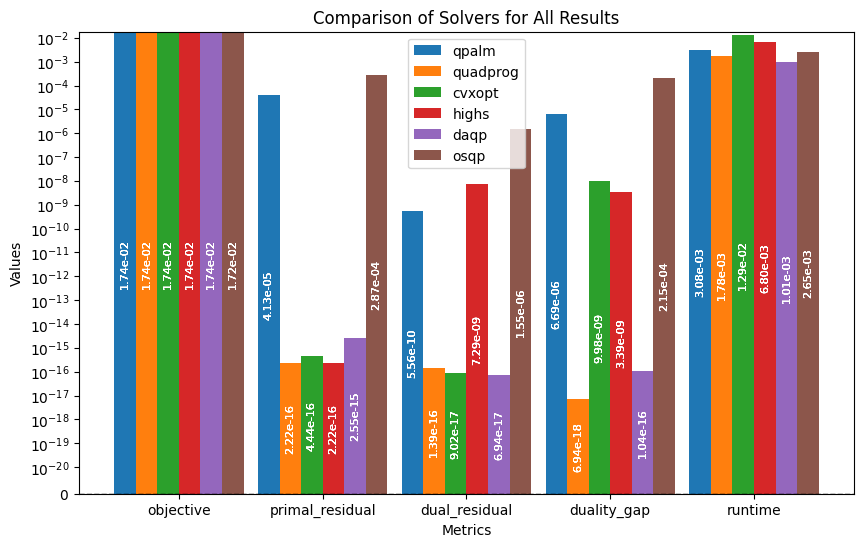

In [6]:
print(results)

numeric_results = results.drop("solution_found")

solvers = numeric_results.columns.values
metrics = numeric_results.index.values

x = np.arange(len(metrics))
width = 0.15

fig, ax = plt.subplots(figsize=(10, 6))

for i, solver in enumerate(solvers):
    bars = ax.bar(x + i * width, numeric_results[solver].values, width, label=solver)
    for bar in bars:
        ax.bar_label(bars, fmt="%.2e", rotation=90, fontsize=8, label_type="center", color="white")

ax.set_xlabel("Metrics")
ax.set_ylabel("Values")
ax.set_title("Comparison of Solvers for All Results")
ax.set_xticks(x + (len(solvers) - 1)/2 * width)
ax.set_xticklabels(metrics)
ax.set_yscale("symlog", linthresh=1e-20)
ax.axhline(y=0, color='black', linewidth=1, linestyle='--')
ax.legend(loc="upper left", bbox_to_anchor=(1, 1))



ax.legend()
plt.show()

## 2. Analytical Solution to Minimum-Variance Problem

(5 points)

- Create a `MinVariance` class that follows the structure of the `MeanVariance` class.
- Implement the `solve` method in `MinVariance` such that if `solver_name = 'analytical'`, the analytical solution is computed and stored within the object (if such a solution exists). If not, call the `solve` method from the parent class.
- Create a `Constraints` object by injecting the same ids as in part 1.b) and add a budget constraint.
- Instantiate a `MinVariance` object by setting `solver_name = 'analytical'` and passing instances of `Constraints` and `Covariance` as arguments.
- Create an `OptimizationData` object that contains an element `return_series`, which consists of the synthetic data generated in part 1.a).
- Solve the optimization problem using the created `MinVariance` object and compare the results to those obtained in part 1.c).


In [12]:
# Define class MinVariance
class MinVariance(Optimization):

    def __init__(self,
                 constraints: Constraints,
                 covariance: Optional[Covariance] = None,
                 **kwargs):
        super().__init__(
            constraints=constraints,
            **kwargs
        )
        self.covariance = Covariance() if covariance is None else covariance

    def set_objective(self, optimization_data: OptimizationData) -> None:
        X = optimization_data['return_series']
        covmat = self.covariance.estimate(X=X, inplace=False)
        self.objective = Objective(
            P = covmat * 2,
            q = np.array([[1]]*len(X.columns.tolist()), dtype='d').T
        )
        q = np.array([[1]]*len(X.columns.tolist()))
        return None

    def solve(self) -> None:
        if self.params.get('solver_name') == 'analytical':
            ids = self.constraints.ids
            sigma = self.objective.coefficients["P"]/2
            inv_sigma = np.linalg.inv(sigma)
            A = np.array(self.constraints.budget['Amat'], dtype='d').reshape(1, -1)
            b = np.array([[self.constraints.budget['rhs']]], dtype='d')
            x = inv_sigma @ A.T @ np.linalg.inv(A @ inv_sigma @ A.T) @ b

            self.results.update({
                'weights': {ids[i]: float(x[i][0]) for i in range(len(ids))},
                'status': True
            })
            return None
        else:
            return super().solve()


# Create a constraints object with just a budget constraint
constraints = Constraints(ids = df.columns.tolist())
constraints.add_budget(rhs=1, sense="=")

# Instantiate the MinVariance class
min_variance = MinVariance(
    constraints=constraints,
    covariance = Covariance(),
    # solver_name='analytical'
)

# Prepare the optimization data and prepare the optimization problem
optimization_data = OptimizationData(return_series=df)
min_variance.set_objective(optimization_data=optimization_data)

# Solve the optimization problem and print the weights
min_variance.solve()
print(min_variance.results["weights"])

{'Asset_1': 0.0020946619046645853, 'Asset_2': 0.013184400070993443, 'Asset_3': 0.00820899747589336, 'Asset_4': 0.00946142078786497, 'Asset_5': 0.01460382365024162, 'Asset_6': 0.014889291221416617, 'Asset_7': 0.004308470574845528, 'Asset_8': 0.01002442286873723, 'Asset_9': 0.01602254013543913, 'Asset_10': 0.006632881812201682, 'Asset_11': 0.0030329529330213154, 'Asset_12': 0.018161348214227286, 'Asset_13': 0.011865530508947397, 'Asset_14': 0.015393703125403781, 'Asset_15': 0.011577361853259157, 'Asset_16': 0.010365122726748825, 'Asset_17': 0.0075539943426165945, 'Asset_18': 0.01405825650834947, 'Asset_19': 0.00586686287059791, 'Asset_20': 0.01144900067915362, 'Asset_21': 0.009620715992560326, 'Asset_22': 0.0001172212620785555, 'Asset_23': 0.014021906860145579, 'Asset_24': 0.00861337828869356, 'Asset_25': 0.006044200527071884, 'Asset_26': 0.002596998780030442, 'Asset_27': 0.006318789928376311, 'Asset_28': 0.007378026107870869, 'Asset_29': 0.013173673858798316, 'Asset_30': 0.0069659973347